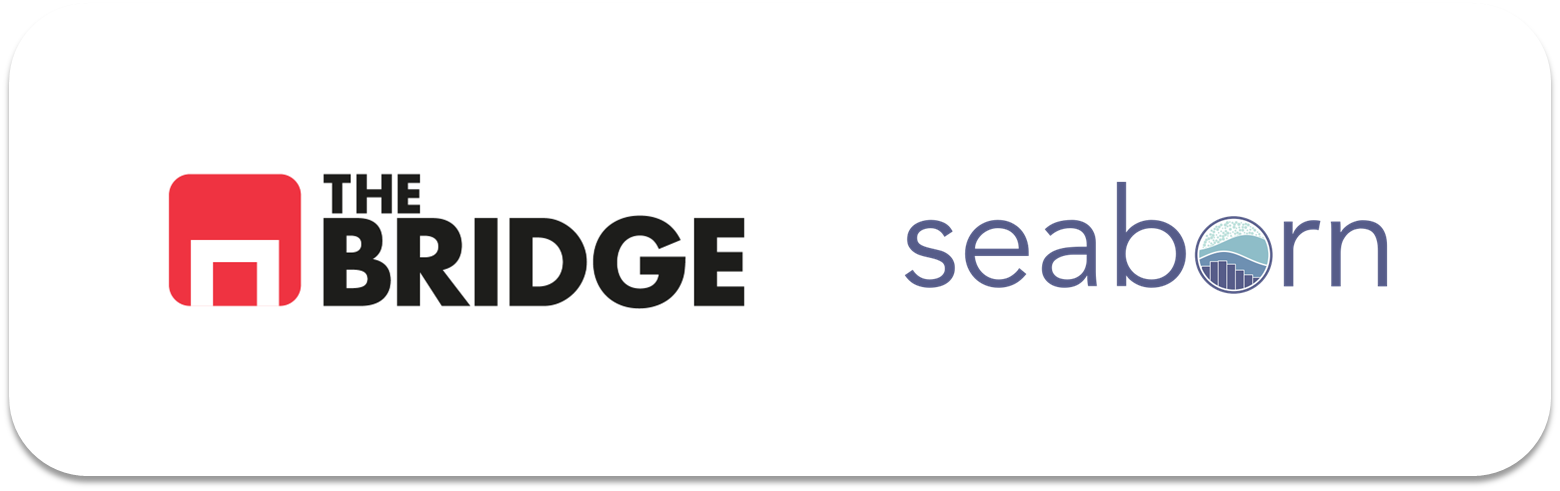

## PRACTICA OBLIGATORIA: **Visualización Avanzada y Presentación**

* La práctica obligatoria de esta unidad se divide en dos partes, una dedicada a visualización y construcción de funciones, y la otra a hacer una presentación de resultados. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [25]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set(color_codes = True)

## #1: Visualización

### #1.1

Carga el dataset de las ciudades de California que está en la ruta "./data/california_cities.csv". Muestra su contenido, deshazte de las filas con nulos.

In [4]:
df = pd.read_csv("./data/california_cities.csv", index_col = 0)
df.dropna(inplace = True)
df

,city,latd,longd,elevation_m,elevation_ft,population_total,area_total_sq_mi,area_land_sq_mi,area_water_sq_mi,area_total_km2,area_land_km2,area_water_km2,area_water_percent
0,Adelanto,34.576111,-117.432778,875.0,2871.0,31765,56.027,56.009,0.018,145.107,145.062,0.046,0.03
1,AgouraHills,34.153333,-118.761667,281.0,922.0,20330,7.822,7.793,0.029,20.260,20.184,0.076,0.37
4,Alhambra,34.081944,-118.135000,150.0,492.0,83089,7.632,7.631,0.001,19.766,19.763,0.003,0.01
5,AlisoViejo,33.575000,-117.725556,127.0,417.0,47823,7.472,7.472,0.000,19.352,19.352,0.000,0.00
6,Alturas,41.487222,-120.542500,1332.0,4370.0,2827,2.449,2.435,0.014,6.342,6.306,0.036,0.57
...,...,...,...,...,...,...,...,...,...,...,...,...,...
477,Yountville,38.403056,-122.362222,30.0,98.0,2933,1.531,1.531,0.000,3.966,3.966,0.000,0.00
478,Yreka,41.726667,-122.637500,787.0,2582.0,7765,10.053,9.980,0.073,26.036,25.847,0.188,0.72
479,YubaCity,39.134722,-121.626111,18.0,59.0,64925,14.656,14.578,0.078,37.959,37.758,0.201,0.53
480,Yucaipa,34.030278,-117.048611,798.0,2618.0,51367,27.893,27.888,0.005,72.244,72.231,0.013,0.02


### #1.2

Crea una función similar a la que se pide en el ejercicio 6 de la segunda tanda de ejercicios del workout. Es decir, una función para pintar diagramas de dispersion que tenga seis argumentos, pero ojo al cambio en el quinto:
1. Un dataframe
2. Una columna numérica del dataframe
3. Una columna numérica del dataframe diferente a la anterior.
4. Un columna categórica (Opcional, valor por defecto None)
5. Un valor para el tamaño de los puntos o una cadena, pero que puede ser una cadena de caracteres, en cuyo caso se debe interpretar como una de las columnas del dataframe cuyos valores deben controlar el tamaño
6. Un sexto argumento "escala", que permita manipular la escala del tamaño en el caso de que el quinto argumento sea una cadena. Este argumento multiplicará a los valores de la columna indicada en el parámetro anterior (así si quiero dividir por 10000, este sexto argumento tendrá que valer 1/10000)

La función debe pintar el diagrama de dispersión de la columna numérica 1, en el eje X, frente a la columna numérica 2, en el eje Y, usando un código de colores en función de la columna categórica y con el tamaño de los puntos según el argumento correspondiente. 

Si no se diera una columna categórica como argumento, el color no debe pasarse como parámetro a la función de Seaborn o Matplotlib que uses.

EXTRA: Añade un argumento que controle si la función pinta una leyenda para colores y tamaños o un colorbar y una leyenda para los tamaños. NO TE PREOCUPES POR EL FORMATO DE LA LEYENDA (lo veremos en la sesión en vivo)

In [9]:
def scatter_plot_with_controls(df, x_col, y_col, color_col = None, size_col = "", scale = 1, legend = True):
    fig, ax = plt.subplots(figsize = (20,10))
    sizes = (100,1000)

    if type(size_col) == str:
        if size_col != "":
            if color_col:
                scatter = sns.scatterplot(x = x_col, y = y_col, size = df[size_col] * scale, data = df, hue = color_col,
                                          alpha = 0.5, palette= "viridis", ax = ax, sizes = sizes,)
            else: 
                scatter = sns.scatterplot(x = x_col, y = y_col, size = df[size_col] * scale, data = df,
                                          alpha = 0.5, palette = "viridis", ax = ax, sizes = sizes,)
        elif color_col:
            scatter = sns. scatterplot(x = x_col, y = y_col, data = df, hue = color_col, alpha = 0.5, palette = "viridis", ax = ax, sizes = sizes,)
    else:
        scatter = sns.scatterplot(x = x_col, y = y_co, soze = size_col, data = df, alpha = 0.5, palette = "viridis", ax = ax, sizes = sizes,)
    
    if legend:
        ax.legend(ncol = 2, loc = "upper right", frameon = False, labelspacing = 2)
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)



In [11]:
df["log_poblacion"] = np.log10(df["population_total"])

### #1.3

Pinta el diagrama de dispersión de longitud y latitud (longitud en las x, latitud en las y) de las ciudades, usando el tamaño de las ciudades para el tamaño de los puntos y los colores para mostrar la población. Previamente crea una columna nueva "log_poblacion" y asignale el log decimal de la poblacion (np.log10() y como argumento los valores de la columna "population_total"). Usa "log_poblacion" para el color.

Un ejemplo de como podría salir para que lo tengas de referencia: (olvidate de la leyenda, auque si quieres como extra puedes intentar ver cómo crearla así)

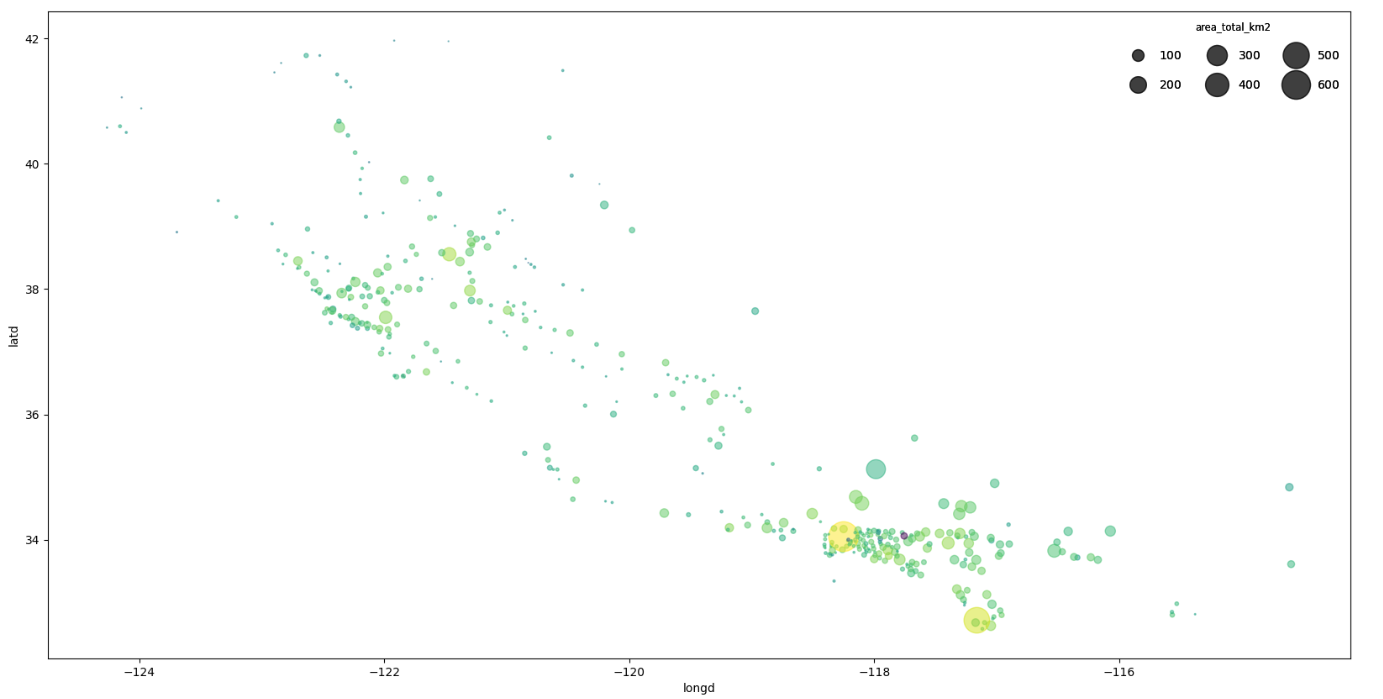

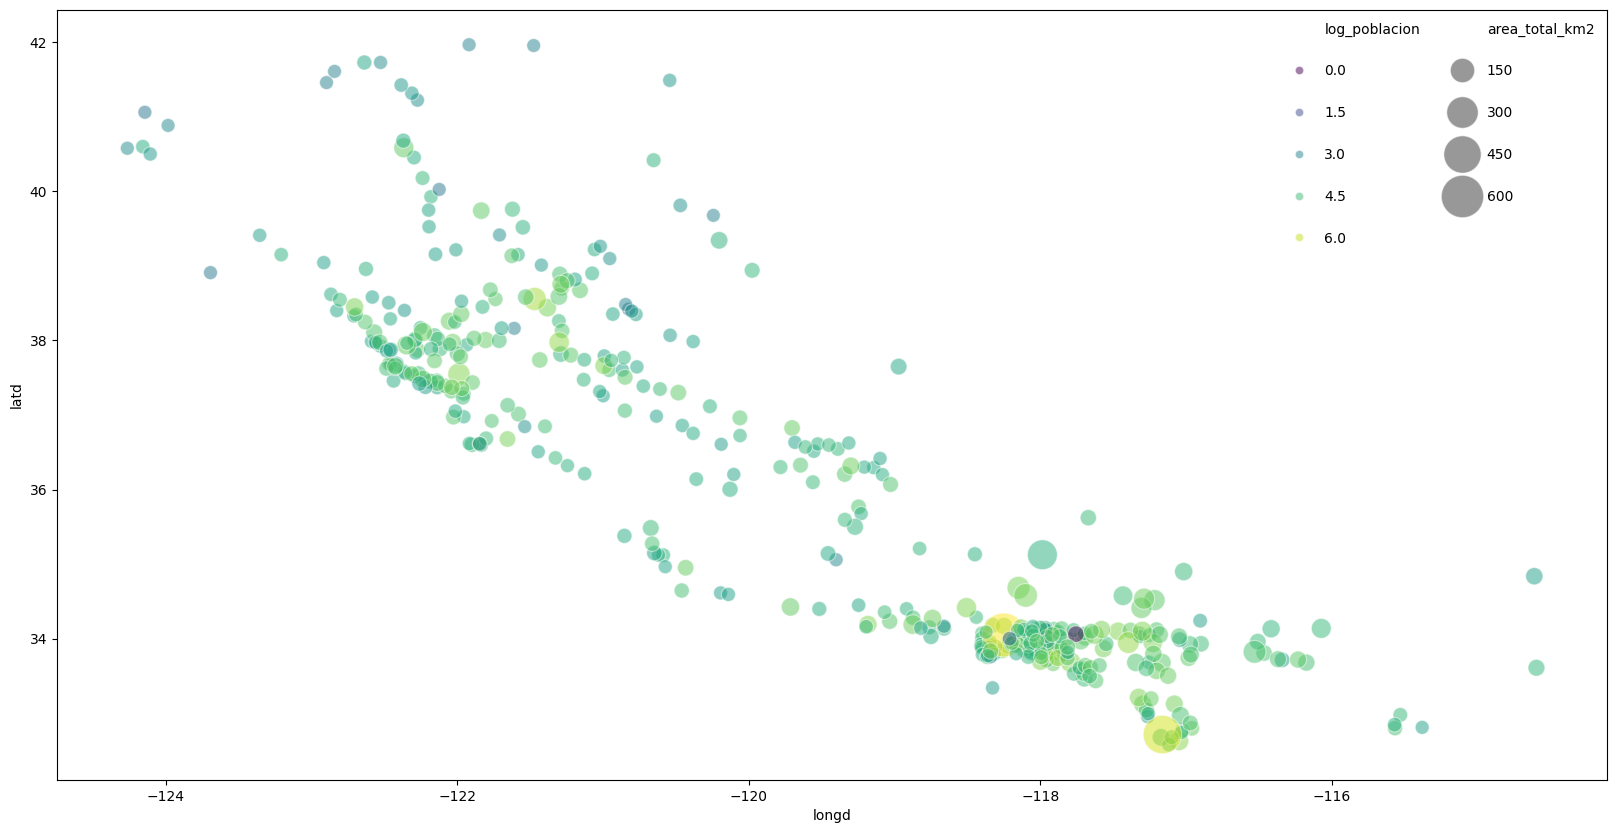

In [12]:
scatter_plot_with_controls(df,
                           "longd",
                           "latd",
                           color_col = "log_poblacion",
                           size_col = "area_total_km2",
                           scale = 1/2,
                           legend = True
                           )

plt.show()

## #2: Presentación

En esta parte tendrás que hacer dos cosas:

#2.1 Crear una presentación sencilla sobre el Titanic de no más de 6 slides, sin incluir portada, con los siguientes mensajes y su apoyo en datos:  

1. El titanic fue un accidente con una tasa de mortalidad alta.  

2. Los datos apoyan que se dio el "Las mujeres y los niños primero", pero...  
3. ...la clase en la que viajases tuvo una influencia significativa y podría explicar...  
4. ...las diferencias entre tasas de supervivencia de mujeres y niños.    
5. Además, aunque el puerto de embarque parece tener influencia, se podría asumir que más bien fue la clase de pasaje que embarcó en cada uno de ellos.  

#2.2 Las gráficas a emplear en la presentación debes generarlas en un notebook.  

Tienes que entregar ambas cosas: presentación y notebook :)

In [15]:
df_titanic = pd.read_csv("./data/titanic.csv")

In [30]:
df_titanic

,survived,pclass,sex,age,sibsp,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,8.0500,S,Third,man,True,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,13.0000,S,Second,man,True,Southampton,no,True
887,1,1,female,19.0,0,30.0000,S,First,woman,False,Southampton,yes,True
888,0,3,female,Sin_Identificar,1,23.4500,S,Third,woman,False,Southampton,no,False
889,1,1,male,26.0,0,30.0000,C,First,man,True,Cherbourg,yes,True


In [22]:
df_titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    object 
 8   class        891 non-null    object 
 9   who          891 non-null    object 
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    object 
 12  embark_town  889 non-null    object 
 13  alive        891 non-null    object 
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 92.4+ KB


In [23]:
df_titanic["age"].sort_values().drop_duplicates().to_list()
df_titanic["age"] = df_titanic["age"].fillna("Sin_Identificar")
df_titanic["embarked"].sort_values().drop_duplicates().to_list()
df_titanic["embarked"] = df_titanic["embarked"].fillna("C")
df_titanic.drop("deck",axis=1,inplace = True)
df_titanic.drop("parch",axis=1,inplace = True)
df_titanic["embark_town"] = df_titanic["embark_town"].fillna("Cherbourg")

In [24]:
df_titanic.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          891 non-null    object 
 4   sibsp        891 non-null    int64  
 5   fare         891 non-null    float64
 6   embarked     891 non-null    object 
 7   class        891 non-null    object 
 8   who          891 non-null    object 
 9   adult_male   891 non-null    bool   
 10  embark_town  891 non-null    object 
 11  alive        891 non-null    object 
 12  alone        891 non-null    bool   
dtypes: bool(2), float64(1), int64(3), object(7)
memory usage: 78.4+ KB


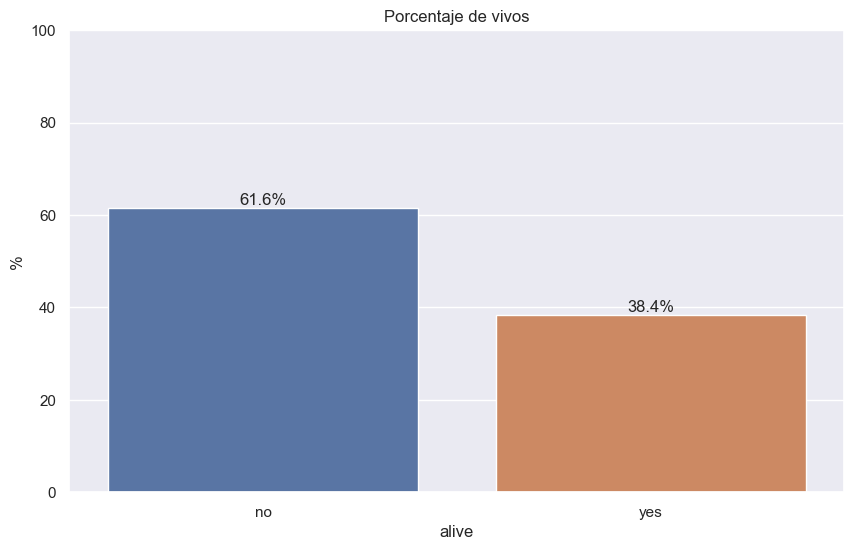

In [75]:
plt.figure(figsize=(10,6))
valores = df_titanic.alive.value_counts(normalize = True) * 100
sns.barplot(x = valores.index, y = valores.values, hue = valores.index)
etiquetas = [f'{v:.1f}%' for v in valores.values]
for i, v in enumerate(valores.values):
        plt.text(i, v, f'{v:.1f}%', ha='center', va='bottom', fontsize=12)
plt.ylim([0,100])
plt.title("Porcentaje de vivos")
plt.ylabel("%");


directorio = "./data"
nombre_imagen = "Porcentaje_de_vivos.png"
ruta_completa = f"{directorio}/{nombre_imagen}"
plt.savefig(ruta_completa)

plt.show()

In [88]:
frecuencias_absolutas = df_titanic["who"].value_counts()
frecuencias_relativas = df_titanic["who"].value_counts(normalize = True) *  100

print(frecuencias_absolutas)
print(frecuencias_relativas)

who
man      537
woman    271
child     83
Name: count, dtype: int64
who
man      60.269360
woman    30.415264
child     9.315376
Name: proportion, dtype: float64


In [89]:
cat_colx = "alive"
cat_coly= "who"
frecuencias_absolutas = df_titanic.groupby(cat_coly, as_index = False)[cat_colx].value_counts()
frecuencias_relativas = df_titanic.groupby(cat_coly, as_index = False)[cat_colx].value_counts(normalize = True)
print(frecuencias_absolutas)
print(frecuencias_relativas)

frecuencias_relativas["proportion"] *= 100

     who alive  count
0  child   yes     49
1  child    no     34
2    man    no    449
3    man   yes     88
4  woman   yes    205
5  woman    no     66
     who alive  proportion
0  child   yes    0.590361
1  child    no    0.409639
2    man    no    0.836127
3    man   yes    0.163873
4  woman   yes    0.756458
5  woman    no    0.243542


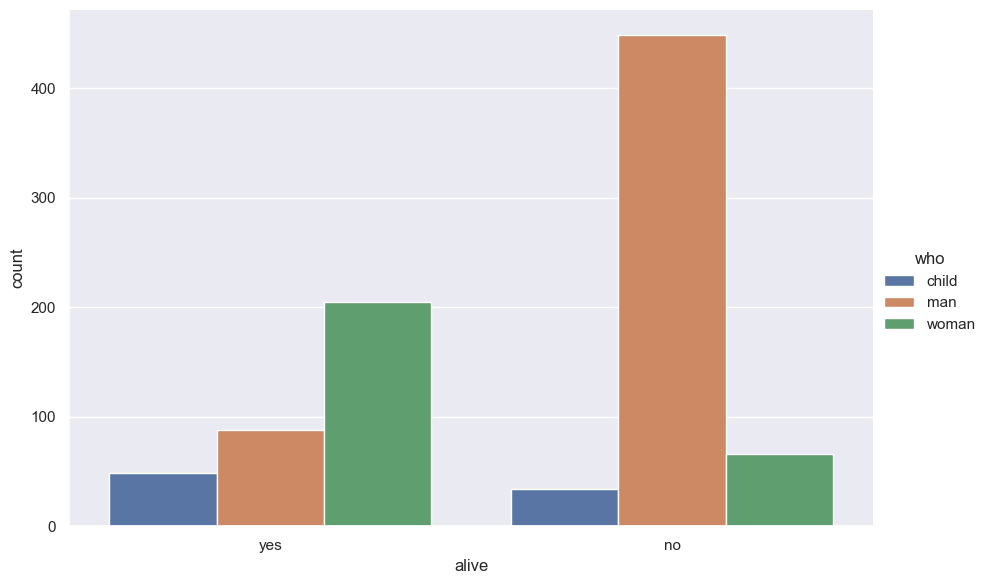

In [107]:
sns.catplot(x = "alive",
            hue = "who",
            kind = "count",
            data = df_titanic.sort_values("who"),
            height = 6,
            aspect = 1.5)

directorio = "./data"
nombre_imagen = "Distribucion_Sexo"
ruta_completa = f"{directorio}/{nombre_imagen}"
plt.savefig(ruta_completa)

plt.show()


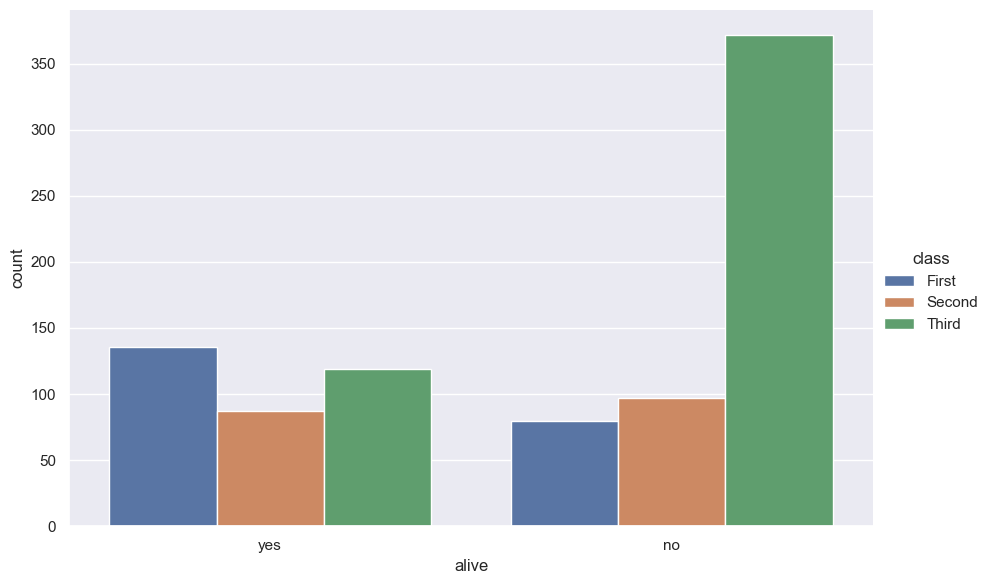

In [100]:
sns.catplot(x = "alive",
            hue = "class",
            kind = "count",
            data = df_titanic.sort_values("class"),
            height = 6,
            aspect = 1.5)

directorio = "./data"
nombre_imagen = "Distribucion_Clase"
ruta_completa = f"{directorio}/{nombre_imagen}"
plt.savefig(ruta_completa)

plt.show()

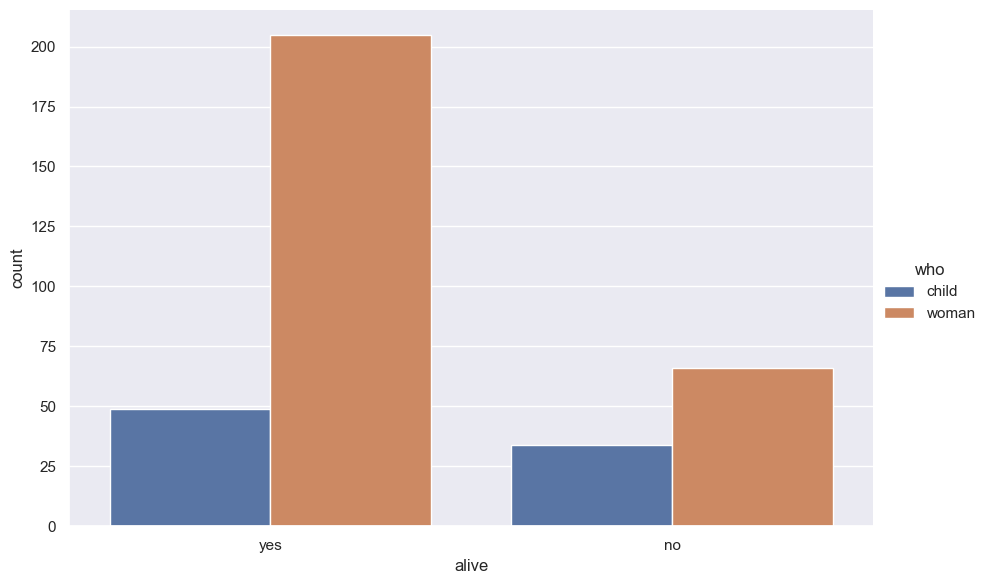

In [108]:
df_niños_mujeres = df_titanic.copy()
df_niños_mujeres
df_niños_mujeres = df_niños_mujeres.drop(df_niños_mujeres[df_niños_mujeres["who"] == "man"].index)
sns.catplot(x = "alive",
            hue = "who",
            kind = "count",
            data = df_niños_mujeres.sort_values("who"),
            height = 6,
            aspect = 1.5)

directorio = "./data"
nombre_imagen = "Distribucion_Sexo_child_Woman"
ruta_completa = f"{directorio}/{nombre_imagen}"
plt.savefig(ruta_completa)

plt.show()